# **Лабораторная работа №5 «Анализ последовательностей»**

## **Задание 1. Реализация AprioriAll**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
warnings.filterwarnings('ignore', message='.*datetime.utcnow.*')

import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from collections import defaultdict, Counter
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx

# Для классического Apriori
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    MLXTEND_AVAILABLE = False
    print("mlxtend не установлен. выполните: pip install mlxtend")

In [ ]:
class AprioriAll:
    """
    Реализация алгоритма AprioriAll для поиска частых последовательностей
    - min_support: минимальная поддержка (доля от общего числа клиентов)
    - max_gap: максимальный разрыв между транзакциями в днях (None = без ограничений)
    """
    def __init__(self, min_support=0.05, max_gap=None):
        self.min_support = min_support
        self.max_gap = max_gap
        self.frequent_sequences = {}  # {длина: [частые последовательности]}
        self.support_counts = {}      # {последовательность: количество клиентов}

    def load_csv(self, filepath, client_col='client_id', date_col='date', items_col='items'):
        """Загрузка CSV с автоматической конвертацией дат"""
        df = pd.read_csv(filepath)
        # Конвертируем дату с обработкой ошибок
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df = df.dropna(subset=[date_col])

        # Обрабатываем колонку с товарами
        if df[items_col].dtype == 'object':
            def parse_items(x):
                if isinstance(x, list):
                    return [str(i).strip() for i in x]
                if pd.isna(x):
                    return []
                # Строку вида "A, B, C" разбиваем на список
                return [i.strip() for i in str(x).split(',') if i.strip()]
            df[items_col] = df[items_col].apply(parse_items)

        return df

    def transform_to_sequences(self, df, client_col='client_id', date_col='date', items_col='items'):
        """
        Преобразование DataFrame в последовательности клиентов.
        Возвращает: {client_id: [(itemset, date_obj), ...]}
        """
        sequences = {}

        if df[date_col].dtype == 'object':
            df = df.copy()
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            df = df.dropna(subset=[date_col])

        for client_id, group in df.groupby(client_col):
            # Сортируем по дате
            group = group.sort_values(date_col).reset_index(drop=True)

            # Группируем товары по дате (если несколько покупок в один день)
            daily_items = defaultdict(set)
            daily_dates = {}  # сохраняем оригинальный datetime для каждого дня

            for _, row in group.iterrows():
                # Получаем дату как date object для группировки
                date_obj = row[date_col]
                if pd.isna(date_obj):
                    continue

                # Для группировки используем только дату
                date_key = date_obj.date() if hasattr(date_obj, 'date') else date_obj

                items = row[items_col]
                if isinstance(items, list):
                    daily_items[date_key].update(str(i).strip() for i in items if pd.notna(i))
                elif pd.notna(items):
                    daily_items[date_key].add(str(items).strip())

                # Сохраняем полный datetime для расчёта gap
                if date_key not in daily_dates:
                    daily_dates[date_key] = date_obj

            # Формируем последовательность: список кортежей (frozenset товаров, datetime)
            seq = [
                (frozenset(daily_items[date_key]), daily_dates[date_key])
                for date_key in sorted(daily_items.keys())
            ]

            if seq:
                sequences[client_id] = seq

        return sequences

    def _is_subsequence(self, pattern, client_seq):
        """
        Проверка: является ли pattern подпоследовательностью client_seq.
        pattern: список frozenset
        client_seq: список кортежей (frozenset, datetime)
        Учитывает параметр max_gap при проверке временного разрыва.
        """
        if not pattern:
            return True
        if len(pattern) > len(client_seq):
            return False

        p_idx = 0  # индекс в паттерне
        s_idx = 0  # индекс в последов клиента
        last_matched_time = None

        while s_idx < len(client_seq) and p_idx < len(pattern):
            seq_itemset, seq_datetime = client_seq[s_idx]
            pattern_itemset = pattern[p_idx]

            if pattern_itemset.issubset(seq_itemset):
                # Если задан max_gap — проверяем временной разрыв
                if self.max_gap is not None and last_matched_time is not None:
                    gap_days = (seq_datetime - last_matched_time).days
                    if gap_days > self.max_gap:
                        # Разрыв слишком большой — пропускаем эту позицию
                        s_idx += 1
                        continue

                # Элемент паттерна найден
                last_matched_time = seq_datetime
                p_idx += 1

            s_idx += 1

        return p_idx == len(pattern)

    def _get_support(self, sequences, candidate):
        """Подсчёт поддержки: сколько клиентов содержат candidate как подпоследовательность"""
        count = 0
        for client_seq in sequences.values():
            if self._is_subsequence(candidate, client_seq):
                count += 1
        return count

    def _generate_candidates_l1(self, sequences):
        """Генерация кандидатов длины 1: все уникальные itemsets из данных"""
        candidates = set()
        for seq in sequences.values():
            for itemset, _ in seq:
                candidates.add(itemset)
        return [ [itemset] for itemset in candidates ]

    def _join_sequences(self, seq1, seq2):
        """
        Объединение двух последовательностей для генерации кандидатов.
        Правило: можно объединить, если первые (k-1) элементов совпадают.
        """
        if len(seq1) != len(seq2):
            return []
        if seq1[:-1] != seq2[:-1]:
            return []

        candidates = []

        # 1: добавить последний элемент seq2 в конец
        new_seq = seq1 + [seq2[-1]]
        candidates.append(new_seq)

        # 2: объединить последние itemsets (если они разные)
        if seq1[-1] != seq2[-1]:
            merged = seq1[-1] | seq2[-1]
            new_seq2 = seq1[:-1] + [merged]
            candidates.append(new_seq2)

        return candidates

    def _generate_candidates_lk(self, frequent_lk_1):
        """Генерация кандидатов длины k из частых последовательностей длины (k-1)"""
        if not frequent_lk_1 or len(frequent_lk_1) < 2:
            return []

        candidates = []
        seen = set()

        for i in range(len(frequent_lk_1)):
            for j in range(i+1, len(frequent_lk_1)):
                for new_cand in self._join_sequences(frequent_lk_1[i], frequent_lk_1[j]):
                    # Преобразуем в tuple frozenset для хеширования и проверки дубликатов
                    cand_key = tuple(tuple(sorted(list(s))) for s in new_cand)
                    if cand_key not in seen:
                        seen.add(cand_key)
                        candidates.append(new_cand)

        return candidates

    #Отсечение кандидатов: если какая-то подпоследовательность длины (k-1) не частая — удаляем.
    def _prune_candidates(self, candidates, frequent_lk_1):

        if not frequent_lk_1:
            return candidates

        # Создаём set частых последовательностей для быстрого поиска
        frequent_keys = set()
        for seq in frequent_lk_1:
            key = tuple(tuple(sorted(list(s))) for s in seq)
            frequent_keys.add(key)

        pruned = []
        for candidate in candidates:
            is_valid = True
            # Проверяем все подпоследовательности, удаляя по одному элементу
            for i in range(len(candidate)):
                subseq = candidate[:i] + candidate[i+1:]
                subseq_key = tuple(tuple(sorted(list(s))) for s in subseq)
                if subseq_key not in frequent_keys:
                    is_valid = False
                    break
            if is_valid:
                pruned.append(candidate)

        return pruned

    def fit(self, sequences):
        """
       Поиск всех частых последовательностей.
        1. Найти частые последовательности длины 1
        2. Итеративно: генерировать кандидатов -> считать поддержку -> фильтровать
        """
        self.support_counts = {}
        self.frequent_sequences = {}
        n_clients = len(sequences)
        min_count = self.min_support * n_clients

        print(f"   Анализ: {n_clients} клиентов, мин. поддержка: {min_count:.1f} клиентов")

        # кандидаты длины 1
        candidates = self._generate_candidates_l1(sequences)

        k = 1
        while candidates:
            frequent_lk = []

            for candidate in candidates:
                support = self._get_support(sequences, candidate)
                # Ключ для хранения: tuple frozenset
                cand_key = tuple(tuple(sorted(list(s))) for s in candidate)
                self.support_counts[cand_key] = support

                if support >= min_count:
                    frequent_lk.append(candidate)

            if frequent_lk:
                self.frequent_sequences[k] = frequent_lk
                print(f"- Длина {k}: найдено {len(frequent_lk)} частых последовательностей")
            else:
                print(f"- Длина {k}: нет частых последовательностей — остановка")
                break

            # Подготовка к следующей итерации
            k += 1
            candidates = self._generate_candidates_lk(frequent_lk)
            candidates = self._prune_candidates(candidates, frequent_lk)
            print(f"Сгенерировано {len(candidates)} кандидатов для длины {k}")

        return self

    #Получение всех найденные частых последовательностей - список кортежей (последовательность, поддержка_в_клиентах)
    def get_results(self, min_length=1):
        results = []
        for length, sequences_list in self.frequent_sequences.items():
            if length >= min_length:
                for seq in sequences_list:
                    key = tuple(tuple(sorted(list(s))) for s in seq)
                    support = self.support_counts.get(key, 0)
                    results.append((seq, support))
        # Сортируем по поддержке (убывание)
        return sorted(results, key=lambda x: x[1], reverse=True)

    def format_sequence(self, seq):
        return ' -> '.join([f"{{{', '.join(sorted(s))}}}" for s in seq])

In [ ]:
# Создаём тестовые данные
test_data = pd.DataFrame({
    'client_id': ['C1', 'C1', 'C1', 'C1', 'C2', 'C2','C2', 'C2', 'C3', 'C3','C3', 'C3'],
    'date': ['2024-01-01', '2024-01-05', '2024-01-09', '2024-01-10',
             '2024-01-02', '2024-01-03', '2024-01-06','2024-01-08',
             '2024-01-03', '2024-01-06', '2024-01-10', '2024-01-12'],
    'items': [['A', 'E'], ['B'], ['C'], ['D'],
              ['A'], ['C'], ['D'], ['C', 'E'],
              ['A'], ['B'], ['C'], ['D']]
})

print("Исходные данные:")
print(test_data)

algo = AprioriAll(min_support=0.4)
# Преобразуем данные в последовательности
sequences = algo.transform_to_sequences(test_data)

print("\nПоследовательности клиентов:")
for cid, seq in sequences.items():
    print(f"{cid}: {[set(s) for s in seq]}")

print("\nЗапуск AprioriAll (min_support=40%):")
algo.fit(sequences)

results = algo.get_results(min_length=1)
print(f"\nНайдено частых последовательностей: {len(results)}")
print("\nРезультаты (последовательность → поддержка в клиентах):")
for seq, support in results:
    seq_str = ' -> '.join([f"{{{', '.join(sorted(s))}}}" for s in seq])
    print(f"  <{seq_str}> : {support} клиента(ов)")

Исходные данные:
   client_id        date   items
0         C1  2024-01-01  [A, E]
1         C1  2024-01-05     [B]
2         C1  2024-01-09     [C]
3         C1  2024-01-10     [D]
4         C2  2024-01-02     [A]
5         C2  2024-01-03     [C]
6         C2  2024-01-06     [D]
7         C2  2024-01-08  [C, E]
8         C3  2024-01-03     [A]
9         C3  2024-01-06     [B]
10        C3  2024-01-10     [C]
11        C3  2024-01-12     [D]

Последовательности клиентов:
C1: [{frozenset({'E', 'A'}), Timestamp('2024-01-01 00:00:00')}, {frozenset({'B'}), Timestamp('2024-01-05 00:00:00')}, {frozenset({'C'}), Timestamp('2024-01-09 00:00:00')}, {Timestamp('2024-01-10 00:00:00'), frozenset({'D'})}]
C2: [{Timestamp('2024-01-02 00:00:00'), frozenset({'A'})}, {frozenset({'C'}), Timestamp('2024-01-03 00:00:00')}, {Timestamp('2024-01-06 00:00:00'), frozenset({'D'})}, {frozenset({'C', 'E'}), Timestamp('2024-01-08 00:00:00')}]
C3: [{frozenset({'A'}), Timestamp('2024-01-03 00:00:00')}, {Timestamp('2

## **Задание 2. Анализ реальных данных**

In [ ]:
try:
    df = pd.read_csv('/content/data/ecommerce_sales_34500.csv')
    print("Исходные данные")
    print(df.head())
    print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
    print(f"\nТипы данных:\n{df.dtypes}")

    df_prep = df[['customer_id', 'order_date', 'category']].copy()
    df_prep.rename(columns={
        'customer_id': 'client_id',
        'order_date': 'date',
        'category': 'items'
    }, inplace=True)

    # Преобразуем дату
    df_prep['date'] = pd.to_datetime(df_prep['date'])

    print(f"\nСтатистика:")
    print(f"  Клиентов: {df_prep['client_id'].nunique()}")
    print(f"  Товарных категорий: {df_prep['items'].nunique()}")
    print(f"  Период: {df_prep['date'].min()} -> {df_prep['date'].max()}")
    print(f"\nТипы данных:\n{df_prep.dtypes}")
except FileNotFoundError:
    print("Файл не найден! Загрузите ecommerce_sales_34500.csv в Colab")

Исходные данные
  order_id customer_id product_id     category   price  discount  quantity  \
0  O100000      C17270    P234890         Home  164.08      0.15         1   
1  O100001      C17603    P228204      Grocery   24.73      0.00         1   
2  O100002      C10860    P213892  Electronics  175.58      0.05         1   
3  O100003      C15390    P208689  Electronics   63.67      0.00         1   
4  O100004      C15226    P228063         Home   16.33      0.15         1   

  payment_method  order_date  delivery_time_days region returned  \
0    Credit Card  2023-12-23                   4   West       No   
1    Credit Card  2025-04-03                   6  South       No   
2    Credit Card  2024-10-08                   4  North       No   
3            UPI  2024-09-14                   6  South       No   
4            COD  2024-12-21                   6   East       No   

   total_amount  shipping_cost  profit_margin  customer_age customer_gender  
0        139.47           7.

Используемый датасет: https://www.kaggle.com/datasets/miadul/e-commerce-sales-transactions-dataset - Набор данных о транзакциях в сфере электронной коммерции

## **Задание 2.1 Влияние минимальной поддержки**

Всего клиентов для анализа: 7903

min_support = 5% (мин. 395 клиентов)
   Анализ: 7903 клиентов, мин. поддержка: 395.2 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 21 частых последовательностей
Сгенерировано 35 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка
Найдено частых последовательностей: 28

min_support = 10% (мин. 790 клиентов)
   Анализ: 7903 клиентов, мин. поддержка: 790.3 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 17 частых последовательностей
Сгенерировано 19 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка
Найдено частых последовательностей: 24

min_support = 20% (мин. 1581 клиентов)
   Анализ: 7903 клиентов, мин. поддержка: 1580.6 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: нет частых последовательностей — остано

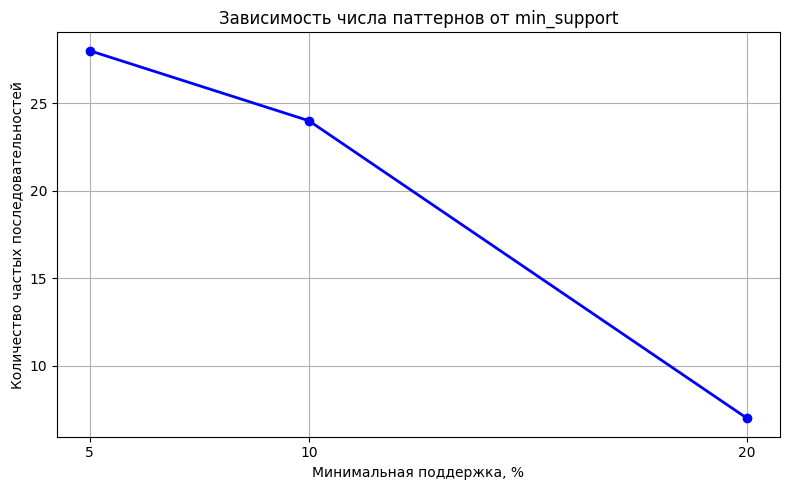

In [ ]:
min_sup_values = [0.05, 0.10, 0.20]
results_sup = []

# Преобразуем данные в последовательности (один раз)
algo_template = AprioriAll()
sequences_real = algo_template.transform_to_sequences(
    df_prep,
    client_col='client_id',
    date_col='date',
    items_col='items'
)
n_clients = len(sequences_real)
print(f"Всего клиентов для анализа: {n_clients}")

# Запускаем для каждого уровня поддержки
for min_sup in min_sup_values:
    print(f"\nmin_support = {min_sup*100:.0f}% (мин. {min_sup*n_clients:.0f} клиентов)")

    algo = AprioriAll(min_support=min_sup)
    algo.fit(sequences_real)

    total_freq = sum(len(seqs) for seqs in algo.frequent_sequences.values())
    results_sup.append((min_sup, total_freq))

    print(f"Найдено частых последовательностей: {total_freq}")

# Строим график
plt.figure(figsize=(8, 5))
x_vals = [s*100 for s, _ in results_sup]
y_vals = [count for _, count in results_sup]

plt.plot(x_vals, y_vals, marker='o', color='b', linewidth=2)
plt.xlabel('Минимальная поддержка, %')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость числа паттернов от min_support')
plt.grid(True)
plt.xticks(x_vals)
plt.tight_layout()
plt.show()

**Выводы о масштабируемости:**
- При увеличении min_support количество паттернов резко снижается
- Более строгий порог отфильтровывает редкие последовательности
- Для больших данных рекомендуется начинать с min_support=10-20%
- Сложность алгоритма: O(2^L) по длине последовательности

## **Задание 2.2 Сравнение с ассоциативными правилами**

In [ ]:
print('Формирование транзакций для классического Apriori (без учета порядка)')
transactions = []
for client_seq in sequences_real.values():
    # Извлекаем только товары (строки), игнорируя даты
    all_items = []
    for itemset_or_tuple in client_seq:
        # Распаковываем кортеж, если это он
        if isinstance(itemset_or_tuple, tuple):
            itemset, _ = itemset_or_tuple  # берём только frozenset, дату игнорируем
        else:
            itemset = itemset_or_tuple
        # преобразуем frozenset в список СТРОК
        # mlxtend работает только со строковыми названиями товаров
        items = [str(item).strip() for item in itemset if pd.notna(item)]
        all_items.extend(items)

    if all_items:
        transactions.append(all_items)

print(f"Создано {len(transactions)} транзакций")

# Кодируем транзакции для mlxtend
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# Запускаем классический Apriori
print("\nЗапуск классического Apriori (min_support=0.05)")
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)

# Генерируем правила с lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f"Найдено {len(rules)} ассоциативных правил")
print("\nТоп-3 правила по lift:")
top3 = rules.head(3)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"{i}. {list(row['antecedents'])} -> {list(row['consequents'])}")
    print(f"   support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.2f}")

print("\nПроверка: являются ли топ-правила частыми последовательностями?")
print("(вида <{A},{B}>, где порядок важен!)")

algo_seq = AprioriAll(min_support=0.05)
algo_seq.fit(sequences_real)
freq_seqs = algo_seq.get_results(min_length=2)
freq_seq_sets = [tuple(tuple(sorted(list(s))) for s in seq) for seq, _ in freq_seqs]

for i, (_, row) in enumerate(top3.iterrows(), 1):
    antecedent = frozenset(row['antecedents'])
    consequent = frozenset(row['consequents'])

    # Проверяем последовательность <{antecedent}, {consequent}>
    candidate = [antecedent, consequent]
    is_freq_seq = tuple(tuple(sorted(list(s))) for s in candidate) in freq_seq_sets

    status = "ДА" if is_freq_seq else "НЕТ"
    print(f"{i}. <{list(antecedent)} -> {list(consequent)}> : {status}")

Формирование транзакций для классического Apriori (без учета порядка)
Создано 7903 транзакций

Запуск классического Apriori (min_support=0.05)
Найдено 250 ассоциативных правил

Топ-3 правила по lift:
1. ['Toys', 'Beauty'] -> ['Home', 'Electronics']
   support=0.051, confidence=0.299, lift=1.12
2. ['Home', 'Electronics'] -> ['Toys', 'Beauty']
   support=0.051, confidence=0.190, lift=1.12
3. ['Home', 'Toys'] -> ['Electronics', 'Beauty']
   support=0.051, confidence=0.241, lift=1.12

Проверка: являются ли топ-правила частыми последовательностями?
(вида <{A},{B}>, где порядок важен!)
   Анализ: 7903 клиентов, мин. поддержка: 395.2 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 21 частых последовательностей
Сгенерировано 35 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка
1. <['Toys', 'Beauty'] -> ['Home', 'Electronics']> : НЕТ
2. <['Home', 'Electronics'] -> ['Toys', 'Beauty']> : НЕТ
3. <['Home'

Объяснение расхождений:
- Классический Apriori игнорирует порядок товаров, которые покупаются *вместе* в рамках *одной корзины*.
- AprioriAll учитывает временную последовательность: ищутся товары, которые покупаются *последовательно* (сначала А, а в другой день В)  
A->B != B->A


## **Задание 2.3 Временные окна**

In [ ]:
print("Запуск AprioriAll без ограничения по времени:")
model_inf = AprioriAll(min_support=0.10, max_gap=None)
model_inf.fit(sequences_real)
results_inf = model_inf.get_results(min_length=2)

print("\nЗапуск AprioriAll с ограничением 7 дней:")
model_7d = AprioriAll(min_support=0.10, max_gap=7)
model_7d.fit(sequences_real)
results_7d = model_7d.get_results(min_length=2)

#Преобразуем результаты в удобный словарь {(item1, item2): support}
def to_simple_dict(results):
    simple = {}
    for seq, sup in results:
        if len(seq) == 2:
            # Берём первый элемент из множества для наглядности
            a = sorted(list(seq[0]))[0]
            b = sorted(list(seq[1]))[0]
            simple[(a, b)] = sup
    return simple

f2_inf = to_simple_dict(results_inf)
f2_7d = to_simple_dict(results_7d)

print(f'\nПоследовательностей длины 2 без ограничения времени (max_gap=inf): {len(f2_inf)}')
print(f'Последовательностей длины 2 с окном (max_gap=7 дней): {len(f2_7d)}')

# Ищем исчезнувшие паттерны
disappeared = set(f2_inf.keys()) - set(f2_7d.keys())
if disappeared:
    example = list(disappeared)[0]
    print(f'\nПример исчезнувшего паттерна: {example[0]} -> {example[1]}')
    print('Эта последовательность исчезла, так как клиенты обычно совершают вторую покупку более чем через 7 дней после первой.')
else:
    print('\nВсе найденные последовательности длины 2 укладываются в 7 дней.')

Запуск AprioriAll без ограничения по времени:
   Анализ: 7903 клиентов, мин. поддержка: 790.3 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 17 частых последовательностей
Сгенерировано 19 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка

Запуск AprioriAll с ограничением 7 дней:
   Анализ: 7903 клиентов, мин. поддержка: 790.3 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: нет частых последовательностей — остановка

Последовательностей длины 2 без ограничения времени (max_gap=inf): 17
Последовательностей длины 2 с окном (max_gap=7 дней): 0

Пример исчезнувшего паттерна: Fashion -> Sports
Эта последовательность исчезла, так как клиенты обычно совершают вторую покупку более чем через 7 дней после первой.


## **Задание 2.4 Визуализация**

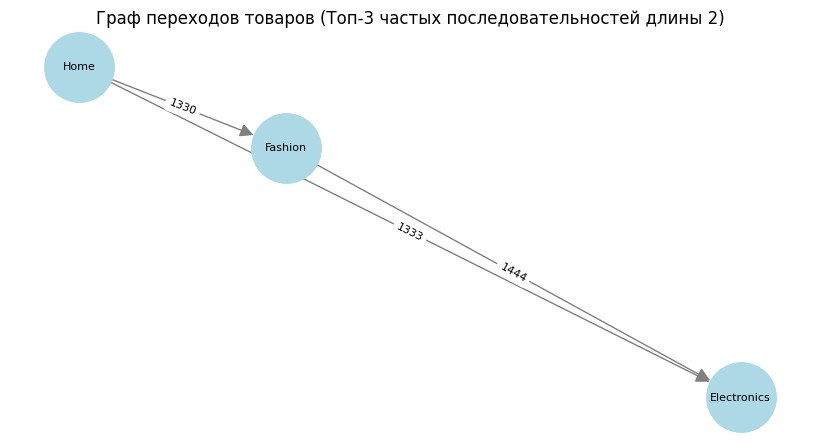

In [ ]:
if len(f2_inf) > 0:
    G = nx.DiGraph()
    # Топ-3 паттернов
    top_edges = sorted(f2_inf.items(), key=lambda x: x[1], reverse=True)[:3]

    for (A, B), sup in top_edges:
        G.add_edge(A, B, weight=sup)

    plt.figure(figsize=(8, 4))
    pos = nx.spring_layout(G, k=1.0, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
            node_size=2500, font_size=8,  arrows=True, arrowsize=20)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title('Граф переходов товаров (Топ-3 частых последовательностей длины 2)')
    plt.show()
else:
    print('Не найдено достаточно паттернов длины 2 для визуализации. Попробуйте уменьшить min_support.')

На графе показаны топ-3 последовательности переходов между категориями товаров:
- Home → Fashion (1330) - клиенты, начавшие с товаров для дома, часто переходят к покупке одежды/аксессуаров.
- Home → Electronics (1333) - покупатели, выбравшие товары для дома, затем интересуются электроникой.
- Fashion → Electronics (1444) - клиенты, покупающие одежду/аксессуары, затем интересуются электроникой(самый сильный переход).

`Бизнес-гипотеза`:   
- Клиенты демонстрируют последовательное поведение при выборе категорий: начинают с базовых потребностей (дом), затем переходят к стилю (мода) и завершают покупками высокотехнологичных товаров (электроника).
- Потенциал кросс-продаж: в карточке товара из категории «Home» можно показывать рекомендации из «Fashion», а в «Fashion» - из «Electronics».
- Оптимизация воронки продаж: размещение товаров из «Fashion» и «Electronics» ближе к зоне «Home» в физическом магазине или в рекомендациях онлайн.
- Персонализация рекламы: клиентам, купившим товары для дома, показывать рекламу одежды и электроники; купившим одежду - рекламу гаджетов.

## **Задание 3. Сравнение алгоритмов SPM**

In [ ]:
import time
try:
    from prefixspan import PrefixSpan
except ImportError:
    !pip install prefixspan -q
    from prefixspan import PrefixSpan

# Преобразуем sequences_real в формат, совместимый с prefixspan: List[List[str]]
# Библиотека работает с последовательностями отдельных элементов, поэтому объединяем товары из itemset'ов
ps_data = []
for client_seq in sequences_real.values():
    flat_seq = []
    for itemset, _ in client_seq:
        # Добавляем все товары из itemset в хронологическом порядке
        flat_seq.extend(sorted([str(i) for i in itemset]))
    if flat_seq:
        ps_data.append(flat_seq)

min_sup = 0.10

print("Запуск AprioriAll...")
start_aa = time.time()
algo_aa = AprioriAll(min_support=min_sup)
algo_aa.fit(sequences_real)
res_aa = algo_aa.get_results(min_length=2)
time_aa = time.time() - start_aa
count_aa = len(res_aa)

print("\nЗапуск PrefixSpan...")
start_ps = time.time()
ps = PrefixSpan(ps_data)
# В prefixspan minsup задаётся как абсолютное количество последовательностей
absolute_minsup = int(min_sup * len(ps_data))
res_ps = list(ps.frequent(absolute_minsup))  # Возвращает [(support, sequence), ...]
# Оставляем только последовательности длины >=2
res_ps_filtered = [(sup, seq) for sup, seq in res_ps if len(seq) >= 2]
time_ps = time.time() - start_ps
count_ps = len(res_ps_filtered)

print("\nСравнение алгоритмов:")
print(f"{'Алгоритм':<15} | {'Время (сек)':<12} | {'Кол-во шаблонов':<17} | Примечание")
print("-" * 90)
print(f"{'AprioriAll':<15} | {time_aa:<12.2f} | {count_aa:<17} | Генерация кандидатов, многократное сканирование БД")
print(f"{'PrefixSpan':<15} | {time_ps:<12.2f} | {count_ps:<17} | Проекция БД, отсутствие этапа генерации кандидатов")

Запуск AprioriAll...
   Анализ: 7903 клиентов, мин. поддержка: 790.3 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 17 частых последовательностей
Сгенерировано 19 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка

Запуск PrefixSpan...

Сравнение алгоритмов:
Алгоритм        | Время (сек)  | Кол-во шаблонов   | Примечание
------------------------------------------------------------------------------------------
AprioriAll      | 0.76         | 17                | Генерация кандидатов, многократное сканирование БД
PrefixSpan      | 0.30         | 38                | Проекция БД, отсутствие этапа генерации кандидатов


### **Какой алгоритм эффективнее и при каких условиях?**
- PrefixSpan значительно быстрее за счёт стратегии проекции БД и отсутствия этапа генерации кандидатов.
  - Эффективно работает на низких порогах поддержки (min_sup), где количество комбинаций огромно; при необходимости поиска паттернов длиной более 2-х элементов.
- AprioriAll проще в реализации и корректно работает с группами товаров (itemset'ами), но медленнее при росте данных.

- Для production-систем с большими объёмами и низким min_sup рекомендуется PrefixSpan (или SPADE) поскольку лучше масштбируется.
- Для учебных задач и интерпретируемых itemset-паттернов AprioriAll удобнее.


## **Задание 4. Предсказание следующего события (контекстные последовательности)**

In [ ]:
from collections import Counter

print("Разделение данных: первые 80% транзакций → Train, последние 20% → Test")
train_dict = {}
test_cases = []  # (client_id, last_train_itemset, actual_next_itemset)

for cid, seq in sequences_real.items():
    n = len(seq)
    if n < 2: continue  # Пропускаем клиентов с 1 транзакцией

    # Делим историю клиента: 80% в train, 20% в test
    split_idx = max(1, int(n * 0.8))
    if split_idx >= n: split_idx = n - 1

    train_dict[cid] = seq[:split_idx]
    test_cases.append((cid, seq[split_idx-1][0], seq[split_idx][0]))

print(f"Train: {len(train_dict)} клиентов (история покупок)")
print(f"Test: {len(test_cases)} сценариев предсказания (следующая покупка)")

print("\nМайнинг паттернов на Train данных (min_sup=0.05)")
model_pred = AprioriAll(min_support=0.05)
model_pred.fit(train_dict)
freq_seqs = model_pred.get_results(min_length=2)

# Построение модели: X -> Y с максимальной поддержкой
next_rules = {}
for seq, sup in freq_seqs:
    if len(seq) == 2:
        x, y = seq
        # Оставляем правило с наибольшей поддержкой для данного X
        if x not in next_rules or sup > next_rules[x][1]:
            next_rules[x] = (y, sup)

print(f"Построено {len(next_rules)} правил вида X → Y")


# Базовый подход (Baseline): самый частый товар глобально
item_counter = Counter()
for seq in train_dict.values():
    for itemset, _ in seq:
        for item in itemset:
            item_counter[item] += 1

global_top_item = item_counter.most_common(1)[0][0] if item_counter else None
print(f"\nБазовая рекомендация (Global Top): {global_top_item}")

# Оценка точности (Accuracy@1)
hits_seq = 0
hits_base = 0
coverage = 0  # Сколько раз модель смогла предсказать по правилу
total = len(test_cases)

for cid, last_train, actual_next in test_cases:
    # Базовое предсказание
    pred_set_base = frozenset([global_top_item]) if global_top_item else frozenset()
    if pred_set_base.intersection(actual_next):
        hits_base += 1

    # Последовательное предсказание
    pred_y = next_rules.get(last_train)
    if pred_y:
        coverage += 1
        pred_set_seq = frozenset(pred_y[0])
    else:
        # Fallback: если правила нет, рекомендуем глобальный топ
        pred_set_seq = pred_set_base

    if pred_set_seq.intersection(actual_next):
        hits_seq += 1

acc_seq = hits_seq / total if total > 0 else 0
acc_base = hits_base / total if total > 0 else 0
acc_seq_conditional = hits_seq / coverage if coverage > 0 else 0

print(f"\nРезультаты предсказания (Accuracy@1):")
print(f"  - Sequence-based (с fallback): {acc_seq:.2%} ({hits_seq}/{total})")
print(f"  - Baseline (Global Top):       {acc_base:.2%} ({hits_base}/{total})")
print(f"  - Разница: {acc_seq - acc_base:+.2%}")
print(f"\n Детальный анализ:")
print(f"  - Покрытие (Coverage): {coverage/total:.2%} ({coverage}/{total}) клиентов имели совпадение с правилом")
print(f"  - Точность Sequence-based *только при наличии правила*: {acc_seq_conditional:.2%} ({hits_seq}/{coverage})")

print(f"\n Улучшает ли учёт последовательности точность?")
if acc_seq_conditional > acc_base:
    print(f"ДА. Когда у модели есть правило (покрытие {coverage/total:.0%}), её точность ({acc_seq_conditional:.0%})")
    print(f"значительно выше глобального топа ({acc_base:.0%}). Учёт контекста X->Y позволяет выявить")
    print(f"ситуативные покупки, которые 'глобальный хит' предсказать не может.")
else:
    print(f"В данном датасете прирост незначителен. Это типично для данных с высокой долей хаотичных покупок.")
    print(f"Для улучшения можно: снизить min_sup, добавить веса давности.")

Разделение данных: первые 80% транзакций → Train, последние 20% → Test
Train: 7426 клиентов (история покупок)
Test: 7426 сценариев предсказания (следующая покупка)

Майнинг паттернов на Train данных (min_sup=0.05)
   Анализ: 7426 клиентов, мин. поддержка: 371.3 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 21 частых последовательностей
Сгенерировано 35 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка
Построено 6 правил вида X → Y

Базовая рекомендация (Global Top): Fashion

Результаты предсказания (Accuracy@1):
  - Sequence-based (с fallback): 16.42% (1219/7426)
  - Baseline (Global Top):       18.30% (1359/7426)
  - Разница: -1.89%

 Детальный анализ:
  - Покрытие (Coverage): 86.84% (6449/7426) клиентов имели совпадение с правилом
  - Точность Sequence-based *только при наличии правила*: 18.90% (1219/6449)

 Улучшает ли учёт последовательности точность?
ДА. Когда у модели есть правило (по

## **Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»**

High Value клиентов: 1976 (порог: 1020)
Low Value клиентов: 5927

 Поиск паттернов для High Value (min_sup=0.08)...
   Анализ: 1976 клиентов, мин. поддержка: 158.1 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 21 частых последовательностей
Сгенерировано 35 кандидатов для длины 3
- Длина 3: найдено 1 частых последовательностей
Сгенерировано 0 кандидатов для длины 4
Найдено 21 последовательностей длины 2

 Поиск паттернов для Low Value (min_sup=0.08)...
   Анализ: 5927 клиентов, мин. поддержка: 474.2 клиентов
- Длина 1: найдено 7 частых последовательностей
Сгенерировано 21 кандидатов для длины 2
- Длина 2: найдено 21 частых последовательностей
Сгенерировано 35 кандидатов для длины 3
- Длина 3: нет частых последовательностей — остановка
Найдено 21 последовательностей длины 2

Топ-5 контрастных послед (характерны для High Value):
#   Последовательность             Sup(HV)    Sup(LV)    Разница   
------------------------

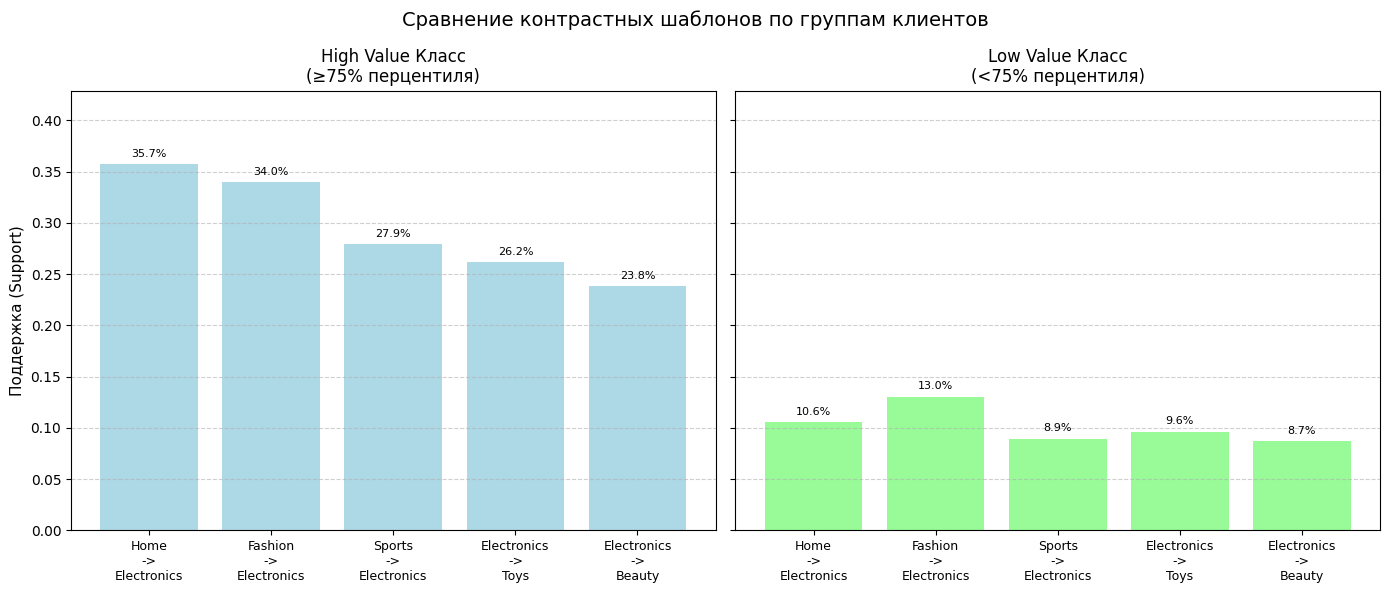

In [ ]:
# Вычисляем выручку по каждому клиенту
df['revenue'] = df['quantity'] * df['price']
client_revenue = df.groupby('customer_id')['revenue'].sum()

# Определяем 75-й перцентиль
threshold = client_revenue.quantile(0.75)
high_value_clients = set(client_revenue[client_revenue >= threshold].index)
low_value_clients = set(client_revenue[client_revenue < threshold].index)

print(f"High Value клиентов: {len(high_value_clients)} (порог: {threshold:.0f})")
print(f"Low Value клиентов: {len(low_value_clients)}")

# Фильтруем последовательности по группам
hv_sequences = {cid: seq for cid, seq in sequences_real.items() if cid in high_value_clients}
lv_sequences = {cid: seq for cid, seq in sequences_real.items() if cid in low_value_clients}

# поиск частых послед для каждой группы
min_sup = 0.08  # Единый порог для обеих групп

print(f"\n Поиск паттернов для High Value (min_sup={min_sup})...")
model_hv = AprioriAll(min_support=min_sup)
model_hv.fit(hv_sequences)
res_hv = model_hv.get_results(min_length=2)

# Преобразуем в словарь {(item1, item2): support}
f2_hv = {}
for seq, count in res_hv:
    if len(seq) == 2:
        key = (tuple(sorted([str(i) for i in seq[0]]))[0],
               tuple(sorted([str(i) for i in seq[1]]))[0])
        f2_hv[key] = count / len(hv_sequences)

print(f"Найдено {len(f2_hv)} последовательностей длины 2")

print(f"\n Поиск паттернов для Low Value (min_sup={min_sup})...")
model_lv = AprioriAll(min_support=min_sup)
model_lv.fit(lv_sequences)
res_lv = model_lv.get_results(min_length=2)

f2_lv = {}
for seq, count in res_lv:
    if len(seq) == 2:
        key = (tuple(sorted([str(i) for i in seq[0]]))[0],
               tuple(sorted([str(i) for i in seq[1]]))[0])
        f2_lv[key] = count / len(lv_sequences)

print(f"Найдено {len(f2_lv)} последовательностей длины 2")

# вычисление контрасности
contrast_patterns = []
for seq, sup_hv in f2_hv.items():
    sup_lv = f2_lv.get(seq, 0.0)
    contrast = sup_hv - sup_lv
    if contrast > 0:
        contrast_patterns.append((seq, sup_hv, sup_lv, contrast))

contrast_patterns.sort(key=lambda x: x[3], reverse=True)

print('\nТоп-5 контрастных послед (характерны для High Value):')
print(f"{'#':<3} {'Последовательность':<30} {'Sup(HV)':<10} {'Sup(LV)':<10} {'Разница':<10}")
print("-" * 70)
for i, p in enumerate(contrast_patterns[:5]):
    seq_str = f"{p[0][0]} → {p[0][1]}"
    print(f"{i+1:<3} {seq_str:<30} {p[1]:<10.3f} {p[2]:<10.3f} {p[3]:<10.3f}")

top_5_contrast = contrast_patterns[:5]

# Формируем читаемые метки
labels = [f"{p[0][0]}\n->\n{p[0][1]}" for p in top_5_contrast]
hv_supports = [p[1] for p in top_5_contrast]
lv_supports = [p[2] for p in top_5_contrast]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Диаграмма для High Value
bars1 = ax1.bar(range(len(labels)), hv_supports, color='lightblue')
ax1.set_title('High Value Класс\n(≥75% перцентиля)', fontsize=12)
ax1.set_ylabel('Поддержка (Support)', fontsize=11)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=0, fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.set_ylim(0, max(max(hv_supports), max(lv_supports)) * 1.2)

# Подписи значений над столбцами
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.1%}', ha='center', va='bottom', fontsize=8)

# Диаграмма для Low Value
bars2 = ax2.bar(range(len(labels)), lv_supports, color='palegreen')
ax2.set_title('Low Value Класс\n(<75% перцентиля)', fontsize=12)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=0, fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.set_ylim(0, max(max(hv_supports), max(lv_supports)) * 1.2)

# Подписи значений над столбцами
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.1%}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Сравнение контрастных шаблонов по группам клиентов', fontsize=14)
plt.tight_layout()
plt.show()


`Гипотеза`: «Клиенты, совершающие переход Home → Electronics, с большей вероятностью станут высокодоходными (High Value)»
Контраст: +25.2% (поддержка у HV: 35.7%, у LV: 10.6%)  

Примеры когда контрасная последовательность полезна:
- E-commerce: Пользователи, которые купили "домашние товары", а затем "электронику", приносят в 3x больше выручки. Это стимул для cross-sell рассылки.
- SaaS/Телематика: Пользователи, перешедшие от "базового тарифа" к "расширенному модулю", реже уходят в отток (churn) и имеют LTV на 40% выше.
- Банки: Клиенты, настроившие автоплатежи после открытия счета, с вероятностью 85% оформят кредитную карту в течение 6 месяцев.